## PIL (Python Imaging Library) 라이브러리
출처 : https://soyoung-new-challenge.tistory.com/112

install Library

In [ ]:
!pip install pillow

In [ ]:
import PIL 
PIL.__version__

## 이미지 데이터
### 1. 이미지 데이터
이미지에 머신러닝을 적용하려면 표 형태의 정형 데이터로 바꿔줘야 한다. 이미지는 정형 데이터로 만들기가 텍스트보다는 간편하다.

##### 1.1 이미지 파일 형식
대표적인 이미지 파일 형식에는 JPEG, PNG, GIF가 있다.

JPEG는 사진 저장을 위한 손실 압축 방식의 표준이다. 흔히 jpg라고 한다. 손실 압축 방식이기 때문에 압축률이 높을 수록 화질이 낮다. 아래 그림의 경우 왼쪽에서 오른쪽으로 갈 수록 압축률이 낮고 화질이 높다. JPEG 파일은 편집과 저장을 반복하면 손실이 누적되서 점점 화질이 나빠진다.
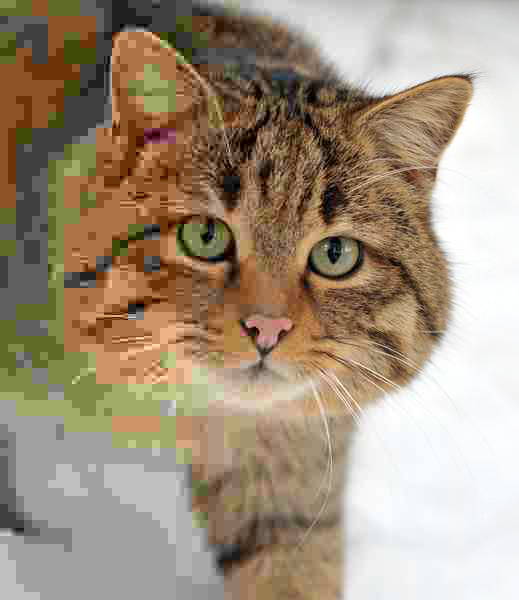
GIF는 미국의 컴퓨서브(CompuServe)사가 개발한 비손실 압축 방식의 이미지 저장 형식이다. PNG는 GIF와 비슷한 국제 표준이다. 소프트웨어 특허로 묶여 있던 GIF를 대신해서 누구나 자유롭게 사용할 수 있도록 만들어졌다.

##### 1.2. 일반적인 이미지 데이터의 구조
JPEG이든 GIF이든, PNG든 파일 형식에 관계 없이 데이터 분석을 위해 이미지를 불러오면 모두 동일한 형태로 변환해서 사용한다. 가장 널리 쓰이는 형식은 이미지를 픽셀 단위로 다루는 것이다. 그림의 점 하나를 픽셀이라고 한다.

각각의 점은 색깔을 나타내는 수치로 표현한다. 흑백의 경우 밝기의 정도를 0에서 255까지로 나타낸다. 0은 검정, 255는 흰색이다. 왜 255까지인가하면 8비트, 즉 2진수 8자리로 나타낼 수 있는 범위가 255까지이기 때문이다. 이정도면 사람의 눈에는 충분하기 때문에 굳이 16비트까지 쓰지는 않는다.

컬러의 경우에는 빛의 삼원색인 빨강(R), 초록(G), 파랑(B) 세 가지를 혼합해서 사용한다. 따라서 점 하나에 RGB를 나타내는 0 ~ 255 범위의 수치 3개로 표현한다. 보통은 표기를 간단히 하기 위해 16진수 표기를 많이 쓰는데 이때는 00~FF로 표시한다. 구글에서 color picker로 검색해서 색상코드를 확인해보자.

##### 1.3. 이미지 행렬
점 하나를 1개(흑백) 또는 3개(컬러)의 수로 나타낸다면 전체 그림은 행렬로 나타낼 수 있다.가로 n, 세로 p 크기의 이미지이면 n행 p열인 행렬로 나타내는 것이다.

행렬 형태는 점들의 위치가 그대로 행렬에서 위치가 되므로 위치를 그대로 보존할 수 있다. 필터 등을 적용하기도 간단하다.

흑백은 1개의 행렬로 나타내지만, 컬러의 경우 RGB별로 3개의 행렬로 나타낸다.

##### 1.4. 이미지 벡터
정형 데이터를 다루는 기계학습 모형은 데이터를 표에서 하나의 행, 즉 벡터로 다룬다. 따라서 이미지를 벡터로 바꾸면 기존의 기계학습 모형에 적용할 수 있다.

가로 n, 세로 p 크기의 이미지는 n × p 크기의 벡터로 나타낸다. 가로 20, 세로 10 크기의 흑백 그림은 크기 200인 벡터로 나타내는 것이다. 컬러의 경우에는 RGB가 모두 들어가야 하니 크기가 600인 벡터가 된다.

일반적으로는 행렬 형태로 전처리를 하고 벡터로 변환하여 최종 예측을 한다.


#### 디스플레이 장치 원리 : https://news.samsungdisplay.com/11678

#### * RGB 이미지 픽셀/채널 : https://velog.io/@kangddong/RGB-%EC%9D%B4%EB%AF%B8%EC%A7%80-%ED%94%BD%EC%85%80%EA%B3%BC-%EC%B1%84%EB%84%90%EC%97%90-%EB%8C%80%ED%95%B4%EC%84%9C

#### * RGBA 이미지 : https://rgbacolorpicker.com/

### 2. Pillow
Pillow는 이미지 처리할 때 사용되는 유용한 라이브러리이다. (공식문서: https://pillow.readthedocs.io/)
##### 2.1. 이미지 파일 찾기

In [ ]:
from PIL import Image  # pillow
import os

##### 2.2. 첫번째 이미지 선택
작업 폴더에 마음에 드는 사진을 넣어둔다.

In [ ]:
image_path = "./data/images/daisy.png"

Pillow 의 Image를 통해 사진을 연다. 

In [ ]:
image = Image.open(image_path)
type(image)

##### 2.3 그림 보기

In [ ]:
image  # 객체 보기

In [ ]:
image.size  # (width, height) <- 행렬과는 다른 순서

##### 2.4 크기 변환

In [ ]:
image_size = (200, 260)
image1 = image.resize(image_size)   # image.resize((200, 260))
image1

##### 2.5. 저장

In [ ]:
image1.save("./data/images/daisy_resized.png")

##### 2.6 회전

In [ ]:
image.rotate(30)  # 시계 반대 방향으로 30도 회전

##### 2.7 반전
상하반전

In [ ]:
image.transpose(Image.FLIP_TOP_BOTTOM)  # 상하 반전

좌우 반전

In [ ]:
Image.FLIP_TOP_BOTTOM, Image.FLIP_LEFT_RIGHT

In [ ]:
image.transpose(Image.FLIP_LEFT_RIGHT) # 좌우 반전

90도로 돌리기

In [ ]:
image.transpose(Image.ROTATE_90)  # 시계 반대 방향으로 90도 회전

rotate(90) 과 다른점은?

In [ ]:
image.rotate(90)  # 틀 고정

##### 2.8. 이미지 필터

Pillow 의 ImageFilter를 통해 사진에 필터링을 할 수 있다.

In [ ]:
from PIL import ImageFilter

블러 처리

In [ ]:
image.filter(ImageFilter.BLUR)  

엠보싱

In [ ]:
image.filter(ImageFilter.EMBOSS)

윤곽

In [ ]:
image.filter(ImageFilter.CONTOUR)

자세히

In [ ]:
image.filter(ImageFilter.DETAIL)

날카롭게

In [ ]:
image.filter(ImageFilter.EDGE_ENHANCE)

부드럽게

In [ ]:
image.filter(ImageFilter.SMOOTH)

##### 2.9. Convert
.convert()에 색상 표현 방식을 넘겨줘서 이미지를 원하는 색상표현으로 변경할 수 있다.

자주 사용되는 방식들은 다음과 같다

- L : 흑백
- RGB : Red, Green, Blue 삼원색을 이용한 색 표현
- RGBA : Red, Green, Blue 삼원색을 이용한 색 표현 방법 + 투명도
- CMYK : Cyan, Magenta, Yellow, Black 을 이용한 색 표현 방법

이미지에 .convert() 함수에 L, RGB, RGBA 등을 넘겨줘서 원하는 색상표현 방식으로 변환할 수 있다.

##### 2.10 흑백
.convert()에 'L'을 넘겨줘서 8 비트 그레이스케일로 변환할 수 있다.

In [ ]:
image.convert('L') # 흑백으로 변환

##### 2.11. 행렬(숫자데이터)로 변환

> PIL image를 Numpy 행렬로 변환하기 위해서는 numpy의 array를 활용한다.

> 그럼 PIL Image를 Numpy로 타입 변환이 가능함

> Numpy로 변환된 이미지의 shape을 확인하면 (height, width, channel) 형태로 출력된다.

In [ ]:
import numpy as np
image_array = np.array(image)
image_array   # PNG 파일이므로 4개 채널이 있음 (RGBA)

행렬의 모양(shape)을 알아보자.

In [ ]:
type(image_array)

In [ ]:
image_array.shape   # 3차원 array, 4개 채널 (RGB + Alpha)

In [ ]:
## PIL Image의 크기 
image.size

In [ ]:
image_array

흑백 이미지를 행렬로 바꿔보자.

In [ ]:
bw_image_array = np.array(image.convert('L'))
bw_image_array.shape   # 흑백이미지(1채널) -> 2차원 array

In [ ]:
bw_image_array

In [ ]:
image.convert('L')

numpy 행렬을 다시 이미지로 바꿀때는...

Image.fromarray() 활용

In [ ]:
from PIL import Image
bw_image = Image.fromarray(bw_image_array)  # numpy array를 PIL Image 객체로 변환
bw_image

흑백 이미지를 bw_image.jpg 로 저장해 보자.

In [ ]:
bw_image.save("./data/images/daisy_bw.jpg") 

In [ ]:
## 이미지 파일 읽기
Image.open('./data/images/daisy_bw.jpg')

##### 2.12 jpg 파일을 읽어와 보자.

In [ ]:
mongol_jpg = Image.open("data/images/mongol.jpg")
mongol_jpg

Image를 Numpy array(행렬)로 변환

In [ ]:
mongol_jpg_array = np.array(mongol_jpg)
mongol_jpg_array.shape  # JPG이므로 R, G, B 3채널

In [ ]:
mongol_jpg_array

In [ ]:
## RED Channel만 추출
mongol_jpg_array[:, :, 0]  # R 채널만 추출

In [ ]:
Image.fromarray(mongol_jpg_array[:, :, 2])  # 0 : RED, 1: Green, 2: Blue

JPG array의 shape를 보면... RGB 3개의 layer가 있음을 알수 있다. 

※ PNG는 RGBA 4개의 layer

In [ ]:
mongol_jpg_array.shape

In [ ]:
mongol_jpg_array

##### 2.12 draw text
사진에 텍스트를 넣어보자

우선 텍스트를 넣을 사진을 불러온다.

In [ ]:
doggy_jpg = Image.open("data/images/doggy.jpg")
doggy_jpg   # display(doggy_jpg)

불러온 이미지를 numpy array로 변환

In [ ]:
doggy_jpg_array = np.array(doggy_jpg)
doggy_jpg_array.shape

In [ ]:
doggy_jpg_array

##### 2.12 텍스트 쓰기


In [ ]:
from PIL import ImageDraw, ImageFont   ## 그리기 준비

jpg 이미지를 png(RGBA)형태로 변환해 준다.

In [ ]:
## RGB -> RGBA 로 변환 (4채널로 변환)
doggy_png = doggy_jpg.convert('RGBA')
doggy_png

In [ ]:
doggy_png_array = np.array(doggy_png)
doggy_png_array.shape

In [ ]:
doggy_png_array

doggy와 같은 크기의 단색 이미지 만들기

In [ ]:
doggy_png.size  # 이미지 크기

In [ ]:
## 새로운 단색 이미지 만들기
Image.new('RGBA', doggy_png.size, (255, 0, 0, 150))  # 반투명 빨간색 단색 이미지 만들기

글씨를 쓰기 위해 흰색-투명으로 이미지와 같은 크기 이미지 준비

In [ ]:
txt_png = Image.new('RGBA', doggy_png.size, (255, 255, 255, 0))   # 흰색 완전투명 이미지
d = ImageDraw.Draw(txt_png)
d  # ImageDraw 객채

In [ ]:
## 글꼴 객체 
font = ImageFont.truetype("malgunbd.ttf", 30)   # 폰트 파일/ 크기 지정

d.text((150, 10), "멍멍이 달리다!!!", fill=(255, 255, 0, 255), font=font) # (위치, 텍스트, 색상(RGBA))
d.text((50, 200), "World", fill=(255, 0, 0, 64), font=font) 

In [ ]:
## 투명한 2개 이미지 합성하기
Image.alpha_composite(doggy_png, txt_png)

In [ ]:
txt_png

In [ ]:
## 순서가 바뀌면 불투명한 이미지가 투명이미지를 덮어버림
Image.alpha_composite(txt_png, doggy_png)

---

### Image to Numpy array


> PIL image를 Numpy로 변환하기 위해서는 numpy의 array를 활용한다.

> 그럼 PIL Image를 Numpy로 타입 변환이 가능함

> Numpy로 변환된 이미지의 shape을 확인하면 (height, width, channel) 형태로 출력된다.

In [ ]:
import numpy as np
from PIL import Image

hodol_img = Image.open("./data/images/호돌이.jpg")
hodol_img_array = np.array(hodol_img)
print(hodol_img_array.shape)
hodol_img_array

### daisy.png 파일을 읽어와서 array data를 살펴보자.

png 파일은 RGB 로 구성된 jpg 파일에 Alpha값(투명도)가 4번째 요소로 들어가 있다.

4번째 요소를 제거하면 jpg와 동일함


In [ ]:
daisy_png = Image.open("./data/images/daisy.png")

daisy_png_array = np.array(daisy_png)
print(daisy_png_array.shape)
daisy_png_array

In [ ]:
## Alpha 채널을 제외하고 RGB 채널만 추출
daisy_png_array[:, :, :3]

In [ ]:
## convert 메서드로 RGBA -> RGB 변환
daisy_jpg = daisy_png.convert('RGB')    
daisy_jpg

In [ ]:
## png array를 jpy array로 변환
daisy_jpg_array = np.array(daisy_png.convert('RGB'))
print("PNG파일의 shape: ", daisy_png_array.shape)
print("jpg파일의 shape: ", daisy_jpg_array.shape)

### NumPy 배열을 PIL 이미지로 변환
fromarray 메소드 사용

In [ ]:
PIL_image = Image.fromarray(daisy_jpg_array)
PIL_image

### png파일의 alpha값 조절하기
alpha 값에 해당하는 array를 잘라내 본다.

In [ ]:
daisy_png_array[:, :, 3]  # alpha channel만 추출

In [ ]:
daisy_png_array[:, :, 3].shape

alpha에 해당하는 값(255)만 100으로 조절하기 위해 같은 모양의 array를 만든다.

In [ ]:
np.ones_like(daisy_png_array[:, :, 3]) * 100  # (100/255)% 투명도

투명도 alpha값을 0 ~ 255 사이의 숫자로 조절함에 따라...
png_array의 마지막열이 바뀌는 것을 볼 수 있다.

In [ ]:
daisy_png_array[:, :, 3] = 150  # broadcasting 활용하여 alpha 값 조절
daisy_png_array

In [ ]:
alpha = 100 # 투명도 0~255
daisy_png_array[:, :, 3] = np.ones_like(daisy_png_array[:, :, 3]) * alpha

In [ ]:
daisy_png_array

방금 만든 png_array를 다시 이미지로 바꾼다. (Image.fromarray)

In [ ]:
daisy_png_alpha = Image.fromarray(daisy_png_array)
daisy_png_alpha

이미지를 저장한다.

In [ ]:
daisy_png_alpha.save('data/images/daisy_png_alpha.png')

참고로 이미지 array의 RGB 성분만 뽑아와 보자.

In [ ]:
## RGB 이미지의 성분 각 채널별로 추출하기
rgb = Image.open("data/images/RGB.jpg")
rgb

In [ ]:
## Numpy array로 변환
rgb_array = np.array(rgb)
rgb_array.shape

In [ ]:
## Red 성분만 추출
Image.fromarray(rgb_array[:, :, 0])  # R 채널만 추출

In [ ]:
## Green 성분만 추출
Image.fromarray(rgb_array[:, :, 1])

In [ ]:
## Blue 성분만 추출
Image.fromarray(rgb_array[:, :, 2])

---

#### Library import

In [ ]:
from PIL import Image


#### Image 파일 읽기
> PIL로 읽은 이미지 파일의 크기는 Image.size로 확인이 가능하다.

> 출력은 (width, height)의 튜플 형태로 출력

In [ ]:
hodol = Image.open('data/images/호돌이.jpg')
display(hodol)

In [ ]:
hodol.size

### 이미지 크기 변환
> resize

In [ ]:
# 날씬한 호돌이 만들기
hodol.resize( (200, 400) )

In [ ]:
resize_scale = 0.4  # 40% 크기로 변환
new_size = np.array(hodol.size) * resize_scale
new_size = tuple(new_size.astype(int))  # 정수화/튜플로 변환

In [ ]:
hodol1 = hodol.resize(new_size)
hodol1

### 회전
rotate

In [ ]:
hodol1.rotate(-30)

### 상하 반전
transpose(Image.FLIP_TOP_BOTTOM)

In [ ]:
hodol1.transpose(Image.FLIP_TOP_BOTTOM)

### 좌우 반전

In [ ]:
hodol1.transpose(Image.FLIP_LEFT_RIGHT)

Image Crop (자르기)

In [ ]:
x1, y1, x3, y3 = 0, 0, 500, 300
crop_img = hodol.crop([x1, y1, x3, y3])
crop_img

### [연습 문제 ] 호돌이의 얼굴이 잘 나오도록 이미지를 crop해 보기

In [ ]:
x1, y1, x3, y3 = 180, 100, 450, 400
crop_img = hodol.crop([x1,y1,x3,y3])
crop_img

### Image with drawBox
> 이미지 위에 원하는 좌표의 박스를 그릴 경우 ImageDraw.Draw.rectangle 함수를 사용

> ImageDraw.Draw.rectangle의 인자로는 박스의 좌표를 준다

In [ ]:
from PIL import Image, ImageDraw

draw = ImageDraw.Draw(hodol)
draw.rectangle([50, 100, 200, 300], outline="red")   # 좌상x, 좌상y, 우하x, 우하y
draw.rectangle([0, 30, 150, 400], outline="blue")
display(hodol)

[연습 문제 ] 호돌이의 얼굴을 초록색 사각형 Box로 감싸보자.